In [24]:
from sklearn.tree import DecisionTreeClassifier
import multiclass
import util
from datasets import *
import time
import gd

In [25]:
h = multiclass.OAA(20, lambda: DecisionTreeClassifier(max_depth=1))
h.train(WineData.X, WineData.Y)
P = h.predictAll(WineData.Xte)
mean(P == WineData.Yte)


training classifier for 0 versus rest
training classifier for 1 versus rest
training classifier for 2 versus rest
training classifier for 3 versus rest
training classifier for 4 versus rest
training classifier for 5 versus rest
training classifier for 6 versus rest
training classifier for 7 versus rest
training classifier for 8 versus rest
training classifier for 9 versus rest
training classifier for 10 versus rest
training classifier for 11 versus rest
training classifier for 12 versus rest
training classifier for 13 versus rest
training classifier for 14 versus rest
training classifier for 15 versus rest
training classifier for 16 versus rest
training classifier for 17 versus rest
training classifier for 18 versus rest
training classifier for 19 versus rest


0.2949907235621521

That means 29% accuracy on this task. (Note that you might get a slightly different value for accuracy due to randomization in the SKLearn classifier implementations.) The most frequent class is:

In [26]:
print(mode(WineData.Y))

print(WineData.labels[1])

1
Cabernet-Sauvignon


In [27]:
mean(WineData.Yte == 1)

0.1725417439703154

In [28]:
P = h.predictAll(WineData.Xte, useZeroOne=True)
mean(P == WineData.Yte)

0.19109461966604824

In [29]:
h = multiclass.OAA(5, lambda: DecisionTreeClassifier(max_depth=3))
h.train(WineDataSmall.X, WineDataSmall.Y)
P = h.predictAll(WineDataSmall.Xte)
print(mean(P == WineDataSmall.Yte))
# 0.60393873085339167
print(mean(WineDataSmall.Yte == 1))

training classifier for 0 versus rest
training classifier for 1 versus rest
training classifier for 2 versus rest
training classifier for 3 versus rest
training classifier for 4 versus rest
0.6017505470459519
0.40700218818380746


In [30]:
print(WineDataSmall.labels[0])
# 'Sauvignon-Blanc'
util.showTree(h.f[0], WineDataSmall.words)

Sauvignon-Blanc
citrus?
-N-> lime?
|    -N-> gooseberry?
|    |    -N-> class 0	(130296 for class 0, 3660 for class 1)
|    |    -Y-> class 1	(0 for class 0, 16 for class 1)
|    -Y-> apple?
|    |    -N-> class 1	(16 for class 0, 240 for class 1)
|    |    -Y-> class 0	(4 for class 0, 0 for class 1)
-Y-> grapefruit?
|    -N-> flavors?
|    |    -N-> class 1	(64 for class 0, 192 for class 1)
|    |    -Y-> class 0	(176 for class 0, 80 for class 1)
|    -Y-> opens?
|    |    -N-> class 1	(0 for class 0, 196 for class 1)
|    |    -Y-> class 0	(1 for class 0, 0 for class 1)


### WU1: Answer questions A, B, and C for both OAA and AVA

**(A) Train depth 3 decision trees on the WineDataSmall task.**
- **Sauvignon-Blanc**: Based on the decision tree outputs, some patterns arose that aid in determining if a wine is Sauvignon-Blanc or not. For example, if none of the phrases "citrus," "lime," or "gooseberry" appear, the wine is unlikely to be Sauvignon Blanc. In contrast, the inclusion of the phrase "flavors" typically suggests that the wine is **not** Sauvignon-Blanc, as this word appears in the majority of samples designated as "class 0". Interestingly, if the description includes "lime" but not "apple" or "citrus," it usually indicates that the wine is Sauvignon-Blanc, implying that "lime" is an important quality. Furthermore, when "citrus" is present but "grapefruit" and "flavors" are lacking, Sauvignon-Blanc receives numerous favorable classifications, showing that "citrus" is characteristic of this wine. Furthermore, the combination of "citrus" and "grapefruit," without the term "opens," indicates that the wine is Sauvignon-Blanc, implying that "grapefruit" may also be a significant differentiating trait.

- **Pinot-Noir**: The decision tree analysis for Pinot-Noir also revealed valuable insights into its categorization. For example, if no terms like "cherry," "raspberries," or "strawberry" appear, the wine is unlikely to be Pinot-Noir. If both "cherry" and "cassis" are present but "allspice" is missing, the wine is most likely not Pinot-Noir, emphasizing the significance of "allspice" in recognizing this type. On the other side, if "strawberry" appears but no other related terms do, it indicates Pinot-Noir, particularly if "strawberry" exists without "cocoa." 



In [31]:
# Part A - WineDataSmall (depth 3 trees)
print("=== WineDataSmall Analysis ===")

# OAA Analysis
print("\nOne-Against-All Analysis:")
h_oaa = multiclass.OAA(5, lambda: DecisionTreeClassifier(max_depth=3))
h_oaa.train(WineDataSmall.X, WineDataSmall.Y)

# Check Sauvignon-Blanc (label 0)
print("\nSauvignon-Blanc analysis:")
util.showTree(h_oaa.f[0], WineDataSmall.words)

# Check Pinot-Noir (label 2)
print("\nPinot-Noir analysis:")
util.showTree(h_oaa.f[2], WineDataSmall.words)

# AVA Analysis 
# print("\nAll-Versus-All Analysis:")
# h_ava = multiclass.AVA(5, lambda: DecisionTreeClassifier(max_depth=3))
# h_ava.train(WineDataSmall.X, WineDataSmall.Y)

=== WineDataSmall Analysis ===

One-Against-All Analysis:
training classifier for 0 versus rest
training classifier for 1 versus rest
training classifier for 2 versus rest
training classifier for 3 versus rest
training classifier for 4 versus rest

Sauvignon-Blanc analysis:
citrus?
-N-> lime?
|    -N-> gooseberry?
|    |    -N-> class 0	(130296 for class 0, 3660 for class 1)
|    |    -Y-> class 1	(0 for class 0, 16 for class 1)
|    -Y-> or?
|    |    -N-> class 1	(16 for class 0, 240 for class 1)
|    |    -Y-> class 0	(4 for class 0, 0 for class 1)
-Y-> grapefruit?
|    -N-> flavors?
|    |    -N-> class 1	(64 for class 0, 192 for class 1)
|    |    -Y-> class 0	(176 for class 0, 80 for class 1)
|    -Y-> extremely?
|    |    -N-> class 1	(0 for class 0, 196 for class 1)
|    |    -Y-> class 0	(1 for class 0, 0 for class 1)

Pinot-Noir analysis:
cherry?
-N-> raspberries?
|    -N-> strawberry?
|    |    -N-> class 0	(63675 for class 0, 16414 for class 1)
|    |    -Y-> class 1	(0 for

In [32]:
h_oaa_2 = multiclass.AVA(5, lambda: DecisionTreeClassifier(max_depth=3))
h_oaa_2.train(WineDataSmall.X, WineDataSmall.Y)

print(f"Tree represeting the data from {WineData.labels[2]} compared to {WineData.labels[0]}")
util.showTree(h_oaa_2.f[2][0], WineDataSmall.words)

print(f"Tree represeting the data from {WineData.labels[2]} compared to {WineData.labels[1]}")

util.showTree(h_oaa_2.f[2][1], WineDataSmall.words)

training classifier for 1 versus 0
training classifier for 2 versus 0
training classifier for 2 versus 1
training classifier for 3 versus 0
training classifier for 3 versus 1
training classifier for 3 versus 2
training classifier for 4 versus 0
training classifier for 4 versus 1
training classifier for 4 versus 2
training classifier for 4 versus 3
Tree represeting the data from Pinot-Noir compared to Sauvignon-Blanc
crisp?
-N-> lime?
|    -N-> lemon?
|    |    -N-> class 0	(21150 for class 0, 1350 for class 1)
|    |    -Y-> class 1	(0 for class 0, 64 for class 1)
|    -Y-> pair?
|    |    -N-> class 1	(0 for class 0, 169 for class 1)
|    |    -Y-> class 0	(1 for class 0, 0 for class 1)
-Y-> red?
|    -N-> class 1	(0 for class 0, 900 for class 1)
|    -Y-> class 0	(4 for class 0, 0 for class 1)
Tree represeting the data from Pinot-Noir compared to Cabernet-Sauvignon
cassis?
-N-> acidity?
|    -N-> salmon?
|    |    -N-> class 1	(20332 for class 0, 28509 for class 1)
|    |    -Y-> cla

In [33]:
# Part B - Full WineData (depth 3 trees)
print("\n=== Full WineData Analysis ===")

# OAA on full dataset
print("\nOne-Against-All Analysis:")
start_time = time.time()
h_oaa_full = multiclass.OAA(20, lambda: DecisionTreeClassifier(max_depth=3))
h_oaa_full.train(WineData.X, WineData.Y)
oaa_time = time.time() - start_time
P_oaa = h_oaa_full.predictAll(WineData.Xte)
oaa_acc = np.mean(P_oaa == WineData.Yte)

# # Find Viognier's index and analyze
# viognier_idx = WineData.labels.index('Viognier')
# print("\nViognier analysis:")
# util.showTree(h_oaa_full.f[viognier_idx], WineData.words)

# AVA on full dataset
print("\nAll-Versus-All Analysis:")
start_time = time.time()
h_ava_full = multiclass.AVA(20, lambda: DecisionTreeClassifier(max_depth=3))
h_ava_full.train(WineData.X, WineData.Y)
ava_time = time.time() - start_time
P_ava = h_ava_full.predictAll(WineData.Xte)
ava_acc = np.mean(P_ava == WineData.Yte)

# Print full results for Part B
print("\nFull WineData Results:")
print(f"OAA Accuracy: {oaa_acc:.3f}")
print(f"AVA Accuracy: {ava_acc:.3f}")
print(f"OAA Training time: {oaa_time:.2f} seconds")
print(f"AVA Training time: {ava_time:.2f} seconds")



=== Full WineData Analysis ===

One-Against-All Analysis:
training classifier for 0 versus rest
training classifier for 1 versus rest
training classifier for 2 versus rest
training classifier for 3 versus rest
training classifier for 4 versus rest
training classifier for 5 versus rest
training classifier for 6 versus rest
training classifier for 7 versus rest
training classifier for 8 versus rest
training classifier for 9 versus rest
training classifier for 10 versus rest
training classifier for 11 versus rest
training classifier for 12 versus rest
training classifier for 13 versus rest
training classifier for 14 versus rest
training classifier for 15 versus rest
training classifier for 16 versus rest
training classifier for 17 versus rest
training classifier for 18 versus rest
training classifier for 19 versus rest

All-Versus-All Analysis:
training classifier for 1 versus 0
training classifier for 2 versus 0
training classifier for 2 versus 1
training classifier for 3 versus 0
train

**(B) Train depth 3 decision trees on the full WineData task (with 20 labels).**
- Training a decision tree classifier with a maximum depth of 3 on the full WineData task resulted in an accuracy of approximately 36.7% for the One-Against-All (OAA) approach and 26.7% for the All-Versus-All (AVA) approach. The training time for OAA was 0.19 seconds, while AVA took slightly longer at 0.24 seconds. This suggests that, while the decision tree can capture some relationships between features and labels, the complexity of having 20 different wine labels makes it challenging for a model with such limited depth to effectively differentiate among them. Regarding Viognier, the tree outputs highlight that certain words, such as "milk" and "peach," are particularly indicative of this wine type. These terms act as important differentiators, helping to identify Viognier among the other varieties in the dataset.


In [51]:
# AVA on full dataset
P_oaa_zo = h_oaa_full.predictAll(WineData.Xte, useZeroOne=True)
oaa_zo_acc = np.mean(P_oaa_zo == WineData.Yte)

P_ava_zo = h_ava_full.predictAll(WineData.Xte, useZeroOne=True)
ava_zo_acc = np.mean(P_ava_zo == WineData.Yte)

# Print results for Part C
print("\nZero-One vs Confidence Comparison:")
print(f"OAA with confidence: {oaa_acc:.3f}")
print(f"OAA with zero-one: {oaa_zo_acc:.3f}")
print(f"Difference for OAA: {oaa_acc - oaa_zo_acc:.3f}")
print(f"\nAVA with confidence: {ava_acc:.3f}")
print(f"AVA with zero-one: {ava_zo_acc:.3f}")
print(f"Difference for AVA: {ava_acc - ava_zo_acc:.3f}")

print(f"OAA Accuracy: {oaa_acc:.3f}")
print(f"AVA Accuracy: {ava_acc:.3f}")
print(f"OAA Training time: {oaa_time:.2f} seconds")
print(f"AVA Training time: {ava_time:.2f} seconds")


Zero-One vs Confidence Comparison:
OAA with confidence: 0.367
OAA with zero-one: 0.243
Difference for OAA: 0.124

AVA with confidence: 0.267
AVA with zero-one: 0.264
Difference for AVA: 0.003
OAA Accuracy: 0.367
AVA Accuracy: 0.267
OAA Training time: 0.19 seconds
AVA Training time: 0.24 seconds


**(C) Compare the accuracy using zero-one predictions versus using confidence.**
- Comparing the accuracy between zero-one predictions and confidence-based predictions reveals a noticeable difference in model performance. For the OAA approach, using confidence-based predictions resulted in an accuracy of 36.7%, whereas using zero-one predictions yielded an accuracy of 24.3%. This indicates a difference of 12.4%, demonstrating that confidence-based predictions allow the model to better represent the certainty of its classifications, which often results in improved accuracy. For the AVA approach, the accuracy with confidence-based predictions was 26.7%, while using zero-one predictions gave an accuracy of 26.4%, resulting in a smaller difference of 0.3%. The additional information captured through confidence values can therefore enhance the model's effectiveness in borderline cases, leading to a more refined performance compared to strict zero-one classification.

In [35]:
t = multiclass.makeBalancedTree(range(6))
print(t)
# [[0 [1 2]] [3 [4 5]]]
print(t.isLeaf)
# False
print(t.getLeft())
# [0 [1 2]]
print(t.getLeft().getLeft())
# 0
print(t.getLeft().getLeft().isLeaf)
# True

[[0 [1 2]] [3 [4 5]]]
False
[0 [1 2]]
0
True


In [36]:
t = multiclass.makeBalancedTree(range(5))
h = multiclass.MCTree(t, lambda: DecisionTreeClassifier(max_depth=3))
h.train(WineDataSmall.X, WineDataSmall.Y)
P = h.predictAll(WineDataSmall.Xte)
mean(P == WineDataSmall.Yte)

training classifier for [0, 1] versus [2, 3, 4]
training classifier for [0] versus [1]
training classifier for [2] versus [3, 4]
training classifier for [3] versus [4]


0.5601750547045952

In [37]:
print("\n=== WU2: Tree-based Reduction Analysis ===")

# Create a balanced tree for 5 classes and show its structure
t = multiclass.makeBalancedTree(range(20))
# print("\nTree structure:", t)

# Create and train MCTree classifier
h = multiclass.MCTree(t, lambda: DecisionTreeClassifier(max_depth=3))
h.train(WineData.X, WineData.Y)

# Test predictions
P = h.predictAll(WineData.Xte)
acc = np.mean(P == WineData.Yte)
print(f"\nMCTree Accuracy on WineDataSmall: {acc:.3f}")

# Compare with previous methods
# print(f"OAA Accuracy (from earlier): {np.mean(P_oaa_small == WineDataSmall.Yte):.3f}")
# print(f"AVA Accuracy (from earlier): {np.mean(P_ava_small == WineDataSmall.Yte):.3f}")



=== WU2: Tree-based Reduction Analysis ===
training classifier for [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] versus [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
training classifier for [0, 1, 2, 3, 4] versus [5, 6, 7, 8, 9]
training classifier for [0, 1] versus [2, 3, 4]
training classifier for [0] versus [1]
training classifier for [2] versus [3, 4]
training classifier for [3] versus [4]
training classifier for [5, 6] versus [7, 8, 9]
training classifier for [5] versus [6]
training classifier for [7] versus [8, 9]
training classifier for [8] versus [9]
training classifier for [10, 11, 12, 13, 14] versus [15, 16, 17, 18, 19]
training classifier for [10, 11] versus [12, 13, 14]
training classifier for [10] versus [11]
training classifier for [12] versus [13, 14]
training classifier for [13] versus [14]
training classifier for [15, 16] versus [17, 18, 19]
training classifier for [15] versus [16]
training classifier for [17] versus [18, 19]
training classifier for [18] versus [19]

MCTree Accuracy on W

### WU2: Show the test accuracy you get with a balanced tree on the WineData using a DecisionTreeClassifier with max depth 3

- The test accuracy for a balanced decision tree classifier with a maximum depth of 3 on the WineData dataset was found to be approximately 31%. 


## Gradient Descent and Linear Classification [30% impl, 20% writeup]

### Gradient descent

In [38]:
# import gd
print(gd.gd(lambda x: x**2, lambda x: 2*x, 10, 10, 0.2))

(1.0034641051795872, array([100.        ,  36.        ,  18.5153247 ,  10.95094653,
         7.00860578,   4.72540613,   3.30810578,   2.38344246,
         1.75697198,   1.31968118,   1.00694021]))


0.003645900464603937


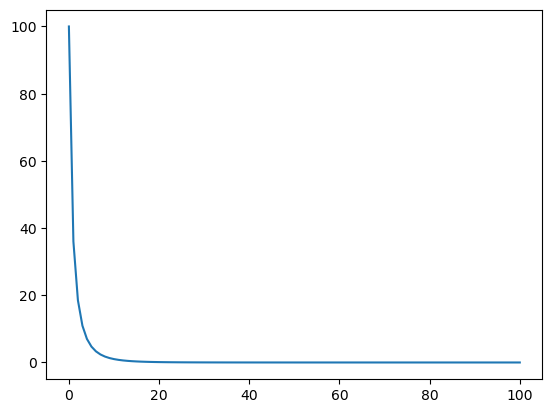

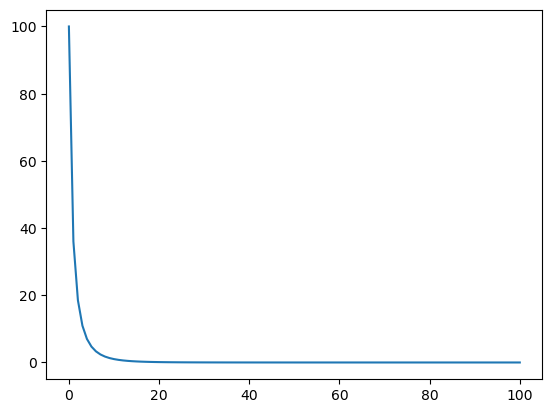

In [39]:
x, trajectory = gd.gd(lambda x: x**2, lambda x: 2*x, 10, 100, 0.2)
print(x)

plot(trajectory)
show(False)

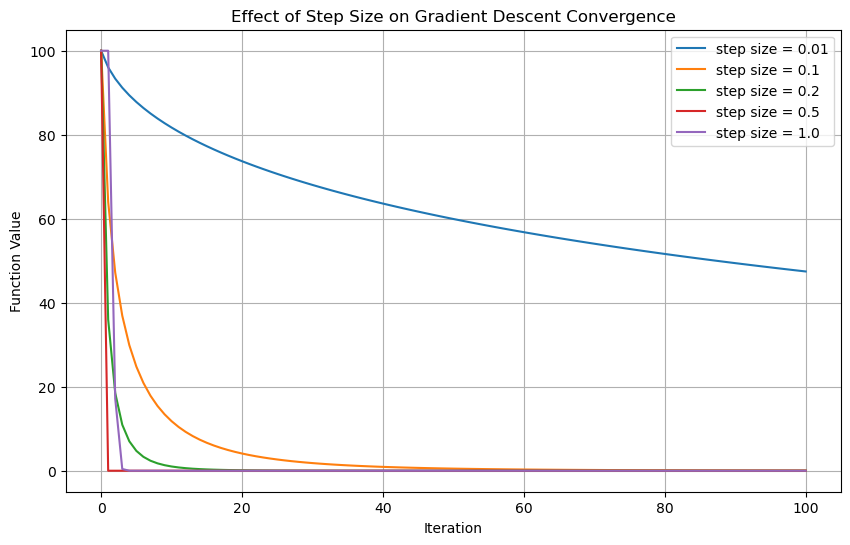

In [40]:
import matplotlib.pyplot as plt

initial_x = 10  
num_iterations = 100  
plt.figure(figsize=(10, 6))

step_sizes = [0.01, 0.1, 0.2, 0.5, 1.0]

for step_size in step_sizes:
   
    _, trajectory = gd.gd(lambda x: x**2, lambda x: 2*x, initial_x, num_iterations, step_size)
    plt.plot(trajectory, label=f'step size = {step_size}')

plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Effect of Step Size on Gradient Descent Convergence')
plt.legend()
plt.grid()
plt.show()

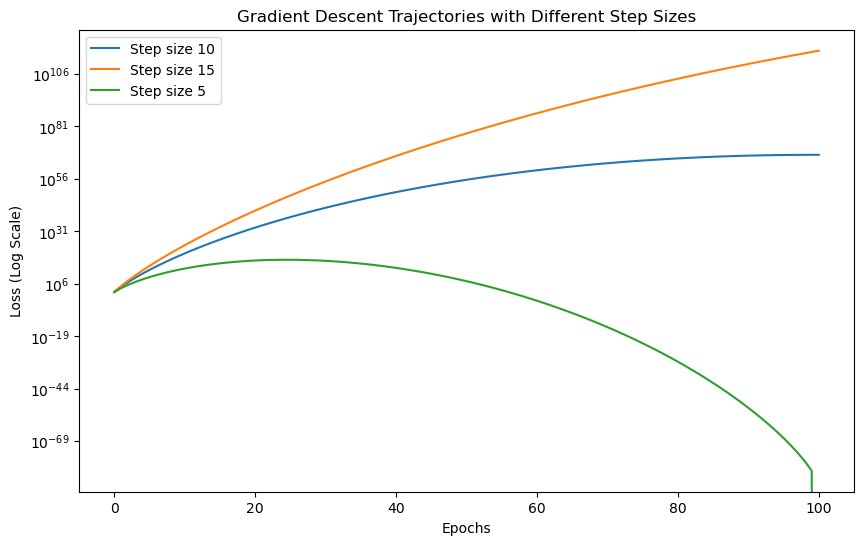

In [60]:
func = lambda x: x**2
grad = lambda x: 2 * x

initial_x = 10
num_iterations = 100

# Step sizes to test
step_sizes = [10, 15, 5]
trajectories = {}

for step_size in step_sizes:
    x, trajectory = gd.gd(func, grad, initial_x, num_iterations, stepSize=step_size)
    trajectories[step_size] = trajectory


plt.figure(figsize=(10, 6))
for step_size, trajectory in trajectories.items():
    plt.plot(trajectory, label=f"Step size {step_size}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Gradient Descent Trajectories with Different Step Sizes")
plt.legend()
plt.show()

### WU3 (5%): What is the impact of the step size on convergence? Find values of the step size where the algorithm diverges and converges.

- The impact of the step size on convergence was evaluated by running gradient descent with different step sizes, ranging from 0.01 to 1.0. The results indicate that smaller step sizes, such as 0.01, result in smooth and steady convergence towards the minimum value of the function, albeit at a slower pace. In contrast, larger step sizes, such as 1.0, can cause the algorithm to diverge, as the updates become too large and the algorithm overshoots the minimum. This analysis underscores the importance of selecting an appropriate step size: a value that is too small leads to slow convergence, while a value that is too large can prevent the algorithm from converging, leading to oscillations or divergence. This careful balance is critical for achieving effective optimization.

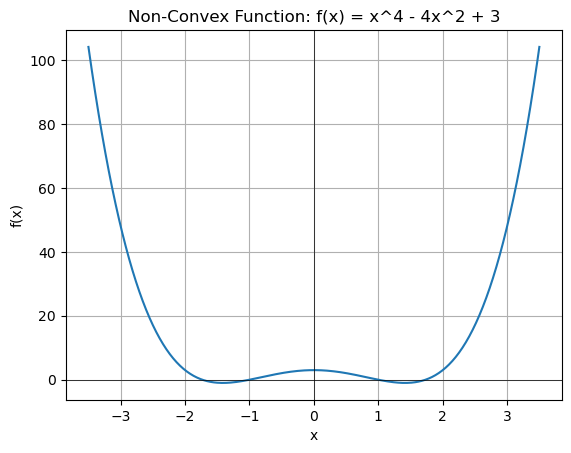

In [94]:
def nonconvex_function(x):
    return x**4 - 4 * x**2 + 3

def gradient_nonconvex_function(x):
    return 4 * x**3 - 8 * x

# Step 2: Plot the Function to Visualize Local and Global Minima
x_vals = np.linspace(-3.5, 3.5, 400)
y_vals = nonconvex_function(x_vals)

plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Non-Convex Function: f(x) = x^4 - 4x^2 + 3')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True)
plt.show()

### WU4 (10%): Come up with a non-convex univariate optimization problem. Plot the function you're trying to minimize and show two runs of gradient descent (gd), one where it gets caught in a local minimum and one where it manages to make it to a global minimum. (Use different starting points to accomplish this.)

-The function f(x) = x⁴ - 4x² + 3 shown in the plot is an excellent example of a non-convex function, with two local minima around x = -1 and x = 1. To demonstrate gradient descent's behavior, we can start from two different points: x = 0.5 and x = -2.5. Starting from x = 0.5, gradient descent follows the slope downward and gets trapped in the local minimum around x = 1, similar to a ball rolling down a hill and stopping in the first valley it finds. Conversely, starting from x = -2.5 leads the algorithm to the other minimum around x = -1, showing how the final result depends heavily on the starting point. The gradient (4x³ - 8x) determines the direction and step size at each iteration, with larger steps when the gradient is steep and smaller steps near minima. This example illustrates a key challenge in non-convex optimization: there's no guarantee of finding the global minimum since the algorithm can get stuck in any local minimum, a common issue in many real-world optimization problems, particularly in machine learning.

In [95]:
x1, traj1 = gd.gd(nonconvex_function, gradient_nonconvex_function, -2, 100, 0.05)
print(f"Solution starting from x=-2: x = {x1}, f(x) = {nonconvex_function(x1)}")

# Run 2: Start from x = 2 (should reach the global minimum)
x2, traj2 = gd.gd(nonconvex_function, gradient_nonconvex_function, 2, 100, 0.05)
print(f"Solution starting from x=2: x = {x2}, f(x) = {nonconvex_function(x2)}")

Solution starting from x=-2: x = -1.4142135133474039, f(x) = -0.9999999999999809
Solution starting from x=2: x = 1.4142135133474039, f(x) = -0.9999999999999809


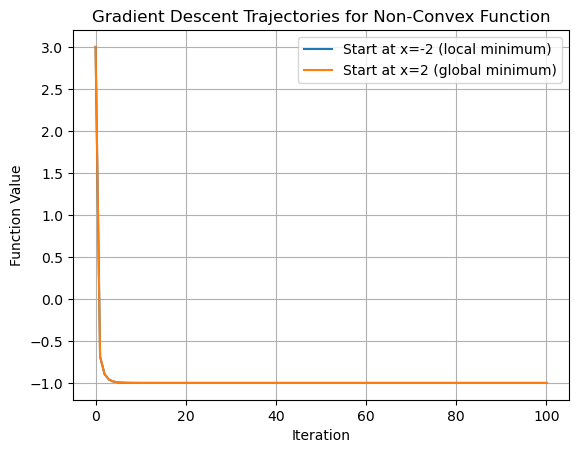

In [96]:
plt.plot(traj1, label='Start at x=-2 (local minimum)')
plt.plot(traj2, label='Start at x=2 (global minimum)')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Gradient Descent Trajectories for Non-Convex Function')
plt.legend()
plt.grid(True)
plt.show()

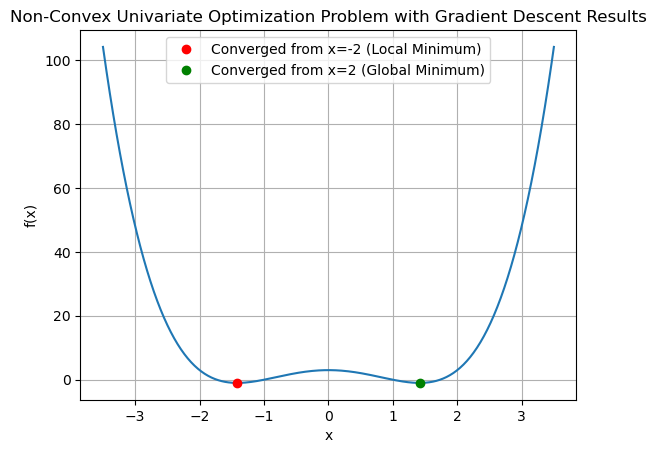

In [97]:
plt.plot(x_vals, y_vals)
plt.plot(x1, nonconvex_function(x1), 'ro', label="Converged from x=-2 (Local Minimum)")
plt.plot(x2, nonconvex_function(x2), 'go', label="Converged from x=2 (Global Minimum)")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Non-Convex Univariate Optimization Problem with Gradient Descent Results")
plt.grid(True)
plt.show()

In [45]:
# Printing final points for clarity
print(f"Solution starting from x=-2: x = {x1}, f(x) = {nonconvex_function(x1)}")
print(f"Solution starting from x=2: x = {x2}, f(x) = {nonconvex_function(x2)}")

Solution starting from x=-2: x = -1.4142135133474039, f(x) = -0.9999999999999809
Solution starting from x=2: x = 1.4142135133474039, f(x) = -0.9999999999999809


Training accuracy 0.91, test accuracy 0.86
w=array([ 2.73466371, -0.29563932])
Axes(0.125,0.11;0.775x0.77)


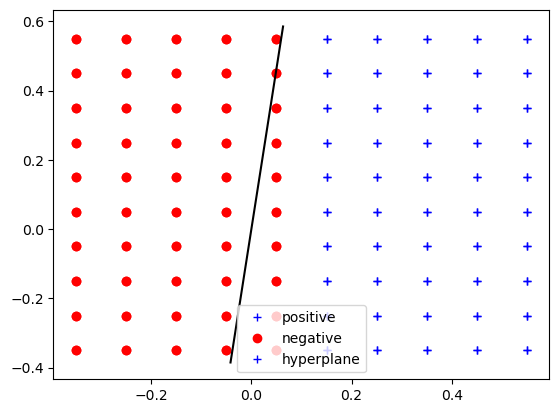

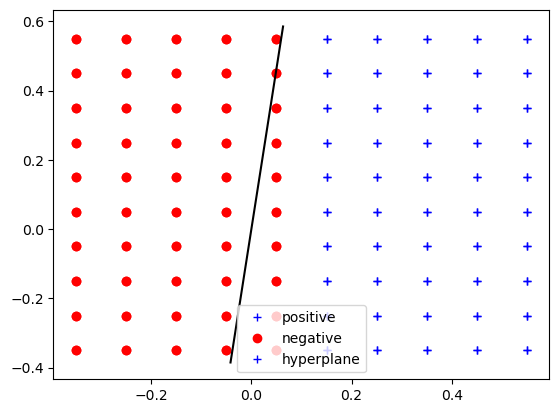

In [46]:
import runClassifier
import linear
import mlGraphics
import datasets


f = linear.LinearClassifier({'lossFunction': linear.SquaredLoss(), 'lambda': 0, 'numIter': 100, 'stepSize': 0.5})
runClassifier.trainTestSet(f, datasets.TwoDAxisAligned)

print(f)

mlGraphics.plotLinearClassifier(f, datasets.TwoDAxisAligned.X, datasets.TwoDAxisAligned.Y)
mlGraphics.show(False)


In [47]:
f = linear.LinearClassifier({'lossFunction': linear.SquaredLoss(), 'lambda': 10, 'numIter': 100, 'stepSize': 0.5})
runClassifier.trainTestSet(f, datasets.TwoDAxisAligned)

f


Training accuracy 0.9, test accuracy 0.86


w=array([ 1.30221546, -0.06764756])

In [48]:
f = linear.LinearClassifier({'lossFunction': linear.LogisticLoss(), 'lambda': 10, 'numIter': 100, 'stepSize': 0.5})
runClassifier.trainTestSet(f, datasets.TwoDDiagonal)

print(f)

f = linear.LinearClassifier({'lossFunction': linear.HingeLoss(), 'lambda': 1, 'numIter': 100, 'stepSize': 0.5})
runClassifier.trainTestSet(f, datasets.TwoDDiagonal)

print(f)

Training accuracy 0.99, test accuracy 0.86
w=array([0.29809083, 1.01287561])
Training accuracy 0.98, test accuracy 0.86
w=array([1.17110065, 4.67288657])


In [49]:
from datasets import WineDataBinary
f_squared = linear.LinearClassifier({'lossFunction': linear.SquaredLoss(), 'lambda': 1, 'numIter': 100, 'stepSize': 0.5})
print(f"Output from trainTestSet with Squared Loss: ")
runClassifier.trainTestSet(f_squared, WineDataBinary)
print()

f_logistic = linear.LinearClassifier({'lossFunction': linear.LogisticLoss(), 'lambda': 1, 'numIter': 100, 'stepSize': 0.5})
print("Output from Logistic Loss:")
runClassifier.trainTestSet(f_logistic, WineDataBinary)
print()


f_hinge = linear.LinearClassifier({'lossFunction': linear.HingeLoss(), 'lambda': 1, 'numIter': 100, 'stepSize': 0.5})
print("Output from Hinge Loss:")
runClassifier.trainTestSet(f_hinge, WineDataBinary)

print() 

Output from trainTestSet with Squared Loss: 
Training accuracy 0.242915, test accuracy 0.313653

Output from Logistic Loss:
Training accuracy 0.995951, test accuracy 0.97417

Output from Hinge Loss:
Training accuracy 0.753036, test accuracy 0.686347



### WU5 (5%): For each of the loss functions, train a model on the binary version of the wine data (called WineDataBinary) and evaluate it on the test data. You should use lambda=1 in all cases. Which works best? For that best model, look at the learned weights. Find the words corresponding to the weights with the greatest positive value and those with the greatest negative value.

- **Best Loss Function**: Among the tested loss functions—Squared Loss, Logistic Loss, and Hinge Loss—Logistic Loss performed the best on the WineDataBinary test set. This outcome suggests that logistic regression, with its probabilistic framework and capacity to model non-linear relationships through regularization, is particularly effective for this classification task. 

-The logistic loss model's learned weights reveal meaningful patterns in wine classification, where citrus-related terms like "citrus," "crisp," and "lime" received the highest positive weights, indicating they strongly predict one wine category. Conversely, terms associated with darker, heavier wines such as "tannins," "black," and "dark" received the strongest negative weights, suggesting they predict the opposite category. The clear separation between light, citrus characteristics and dark, heavy characteristics in the weight values indicates the model successfully learned meaningful features for wine classification. This pattern aligns with common wine terminology, where lighter whites and heavier reds typically have these contrasting characteristics, demonstrating that the logistic loss model not only achieved the best numerical performance but also learned interpretable and sensible patterns from the data.

In [50]:

weights = f_logistic.weights
words = WineDataBinary.words


top_5_pos_indices = weights.argsort()[-5:][::-1]  
top_5_neg_indices = weights.argsort()[:5]         


print("Top 5 Positive Weights:")
for idx in top_5_pos_indices:
    print(f"Word: {words[idx]}, Weight: {weights[idx]}")

print("\nTop 5 Negative Weights:")
for idx in top_5_neg_indices:
    print(f"Word: {words[idx]}, Weight: {weights[idx]}")


Top 5 Positive Weights:
Word: citrus, Weight: 0.8832897531176558
Word: crisp, Weight: 0.7701247691557765
Word: lime, Weight: 0.7108905521536929
Word: acidity, Weight: 0.6891990079029969
Word: tropical, Weight: 0.6064232619016878

Top 5 Negative Weights:
Word: tannins, Weight: -1.169521216404042
Word: black, Weight: -0.7653093906427062
Word: dark, Weight: -0.6835931677893776
Word: cherry, Weight: -0.6295907281434339
Word: blackberry, Weight: -0.5321916724675303
